# Using SciPy distributions

Use a frozen SciPy distribution in a reliability model and check its parameters before running FORM and SORM.

**Before you start:** the introductory tutorial.

In [1]:
import pystra as ra
from scipy.stats import genextreme as gev


Define the limit-state function

In [2]:
def lsf(X1, X2, C):
    return X1 - X2 - C


Create the GEV variable and plot that it is defined as intended:

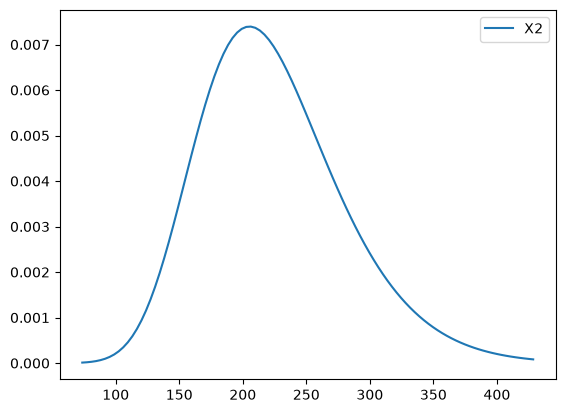

<Axes: >

In [3]:
X2 = ra.ScipyDist("X2", gev(c=0.1, loc=200, scale=50))
X2.plot()


**Figure.** The SciPy GEV probability density shows the distribution produced by its shape, location and scale parameters; these parameters are not its physical mean and standard deviation.

Now create the limit state and stochastic model objects, and add the variables

In [4]:
limit_state = ra.LimitState(lsf)

model = ra.StochasticModel()
model.add_variable(ra.Normal("X1", 500, 100))
model.add_variable(X2)
model.add_variable(ra.Constant("C", 50))


Suppress the console output

In [5]:
options = ra.FORMOptions()


Execute a FORM analysis

In [6]:
form = ra.FORM(
    model=model,
    limit_state=limit_state,
    options=options,
)
form_result = form.run()
print(form_result.summary())


FORM result
  Status                   converged
  Message                  Converged
  Failure probability      0.0249392
  Reliability index        1.961
  Iterations               5
  Limit-state evaluations  39


And then a SORM analysis (passing the existing FORM object for efficiency)

In [7]:
sorm = ra.SORM(model=model, limit_state=limit_state, form=form)
sorm_result = sorm.run()
print(sorm_result.summary())


SORM result
  Status                   converged
  Message                  Fitted
  Failure probability      0.0270706
  Reliability index        1.9257
  Fit                      curve
  FORM reliability index   1.961
  Pf, breitung             0.0270706
  Pf, modified breitung    0.0275476
  Limit-state evaluations  9


## Interpretation

A SciPy shape, location and scale describe that distribution’s own parameterization; they are not generally its mean and standard deviation. Inspect the distribution before interpreting the reliability result.

**Continue:** [User guide](../guides/models.rst) · [API reference](../api/probability.rst) · [Theory](../theory/transformations.rst)